# 03_Preprocessing_and_modeling.ipynb

This is the third notebook of the project, focused on preprocessing and modeling.

This includes preparing train and test sets, encoding and scaling, and model choosing

## 1. Imports

We begin by importing the necessary libraries and the engineered dataset

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost
import joblib
import itertools
import time
import json
import os

In [14]:
df = pd.read_csv("data/engineered.csv")

df.head()

,LIMIT_BAL,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,PAY_AMTSEP,PAY_AMTAUG,PAY_AMTJUL,PAY_AMTJUN,PAY_AMTMAY,PAY_AMTAPR,IS_DEFAULT,PAID_TO_REMAINING_SEP,PAID_TO_REMAINING_AUG,PAID_TO_REMAINING_JUL,PAID_TO_REMAINING_JUN,PAID_TO_REMAINING_MAY,PAID_TO_REMAINING_APR,EAD,CREDIT_UTIL_MEAN,CREDIT_UTIL_TREND
0,620.0,2,2,-1,-1,-2,-2,0.000,21.359,0.0,0.0,0.000,0.000,1,0.000000,0.222115,0.000000,1.000000,1.000000,1.000000,121.303,0.064200,0.042229
1,3720.0,-1,2,0,0,0,2,0.000,31.000,31.0,31.0,0.000,62.000,1,0.000000,0.579710,0.372856,0.305623,0.000000,0.613309,83.142,0.023718,-0.002065
2,2790.0,0,0,0,0,0,0,47.058,46.500,31.0,31.0,31.000,155.000,0,0.051917,0.106937,0.073752,0.069779,0.066899,0.321564,906.409,0.188246,0.020608
3,1550.0,0,0,0,0,0,0,62.000,62.589,37.2,34.1,33.139,31.000,0,0.042562,0.041859,0.024345,0.038850,0.036914,0.033844,1456.690,0.771113,0.094865
4,1550.0,-1,0,-1,0,0,0,62.000,1137.111,310.0,279.0,21.359,21.049,0,0.232099,6.469312,0.279057,0.429799,0.035987,0.035492,267.127,0.364463,-0.044630


In [15]:
# DEFINE INPUT AND TARGET COLUMNS

target_col = "IS_DEFAULT"
input_cols = [col for col in df.columns if col != target_col and col != "EAD"] # Exclude EAD column from training, as previously mentioned

In [16]:
# Quick inspection

pd.set_option('display.max_columns', None) # Show all columns in the output

df.describe()

,LIMIT_BAL,PAY_SEP,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,PAY_AMTSEP,PAY_AMTAUG,PAY_AMTJUL,PAY_AMTJUN,PAY_AMTMAY,PAY_AMTAPR,IS_DEFAULT,PAID_TO_REMAINING_SEP,PAID_TO_REMAINING_AUG,PAID_TO_REMAINING_JUL,PAID_TO_REMAINING_JUN,PAID_TO_REMAINING_MAY,PAID_TO_REMAINING_APR,EAD,CREDIT_UTIL_MEAN,CREDIT_UTIL_TREND
count,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000,29965.000000
mean,5190.702155,-0.016753,-0.131854,-0.164392,-0.218922,-0.264509,-0.289438,175.773079,183.767479,162.182354,149.780141,148.951808,161.866438,0.221258,1.709728,1.594698,1.729699,1.743230,1.210764,1.452664,1589.773303,0.373480,0.022675
std,4022.564192,1.123492,1.196322,1.195878,1.168175,1.132220,1.149090,513.727333,714.657156,546.107195,485.908401,473.877541,551.396283,0.415101,73.226685,40.400010,52.522330,74.344424,16.274950,22.148097,2283.402105,0.351867,0.063539
min,310.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5132.980000,-0.232590,-0.462580
25%,1550.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,31.000000,26.350000,12.090000,9.300000,8.091000,4.061000,0.000000,0.038850,0.038469,0.033478,0.032781,0.036051,0.035971,111.445000,0.030300,-0.005963
50%,4340.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.162000,62.310000,55.924000,46.500000,46.500000,46.500000,0.000000,0.074331,0.075451,0.061567,0.053042,0.060103,0.065751,695.578000,0.285629,0.001558
75%,7440.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,155.248000,155.000000,139.872000,124.496000,125.302000,124.000000,0.000000,0.635102,0.810000,0.847554,0.857843,1.000000,1.000000,2085.060000,0.688454,0.037971
max,31000.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,27080.112000,52212.029000,27777.240000,19251.000000,13222.399000,16388.646000,1.000000,11453.666667,4444.333333,6333.333333,8891.357143,1738.424242,2643.330000,29899.841000,5.364308,1.166823


## 2. Preprocessing

With our feature engineering completed and confirmed by our last EDA, the dataset must be prepared for the predictive modeling stage.

Financial datasets often exhibit features with vastly different physical units and magnitudes. In our current dataframe:
* **Repayment statuses** `PAY_*` is a bounded ordinal metric ranging from -2 to 8; `CREDIT_UTIL_MEAN`, `CREDIT_UTIL_TREND` and `PAID_TO_REMAINING_*` are simple fractions in the range [0,∞)
* **Financial exposures and limits** (`LIMIT_BAL`, `PAY_AMT*`) are continuous monetary values in USD that can scale up to tens of thousands of dollars.

When applying distance-based algorithms (e.g., Support Vector Machines) or regularized linear structures (e.g., Lasso/Ridge Logistic Regression), features with larger raw magnitudes or extreme unconstrained outliers will artificially dominate the objective function optimization, overshadowing critical behavioral signals like payment delays.

To prevent this, we implement a robust preprocessing workflow combining targeted Winsorization/Capping and robust Scaling. To maintain strict integrity and prevent any form of data leakage, all statistical thresholds (such as the 99th percentile for monetary caps) are computed exclusively on the Training set and then broadcasted to the Test set. Fixed caps for `PAID_TO_REMAINING_*` (2.0), `CREDIT_UTIL_MEAN` (1.5) and `CREDIT_UTIL_TREND` (0.3, =30%) are instead hard-coded domain thresholds, not derived from any data statistic, thus leakage-free by construction.

Motivations:
- `PAID_TO_REMAINING_` (2.0, =200%): Values above 2.0 represent situations where the payment amount is more than twice the outstanding balance. In practice, such ratios are usually caused by very small denominators (e.g. negligible remaining debt) and can introduce disproportionate feature magnitudes without representing a materially different repayment behavior
- `CREDIT_UTIL_MEAN` (1.5, =150%): A mean credit utilization above 150% indicates persistent over-limit exposure. Beyond this level, the exact magnitude is less informative than the presence of sustained excessive utilization
- `CREDIT_UTIL_TREND` (0.3, =30%): A sustained average increase of 30 percentage points (relative to `LIMIT_BAL`, not current utilization) per month over six months already represents an extreme deterioration pattern. Larger slopes are rare and mostly indicate extreme outlier trajectories; their additional predictive contribution is expected to be limited compared with the information already captured by the current utilization level (the same logic will be used for DECREASING utilization trend, i.e. a floor of -0.3 will also be set).

In [17]:
# 1. INPUT/TARGET SPLIT

# Get clean copies
df_input = df[input_cols].copy()
df_target = df[target_col].copy()
df_ead = df["EAD"].copy()

train_input, test_input, train_target, test_target, train_EAD, test_EAD = sklearn.model_selection.train_test_split(df_input, df_target, df_ead, test_size=0.20, random_state=42, stratify=df_target)

# Save raw datasets
train_input_raw = train_input.copy()
test_input_raw  = test_input.copy()


# 2. OUTLIER ENGINEERING & WINSORIZATION

# 1. Capping PAID_TO_REMAINING_*
coverage_cols = [f"PAID_TO_REMAINING_{m}" for m in ["SEP","AUG","JUL","JUN","MAY","APR"]]
for col in coverage_cols:
    train_input[col] = train_input[col].clip(upper=2.0)
    test_input[col] = test_input[col].clip(upper=2.0)

# 2. Capping & Flooring CREDIT_UTIL_MEAN
train_input["CREDIT_UTIL_MEAN"] = train_input["CREDIT_UTIL_MEAN"].clip(lower=0.0, upper=1.5)
test_input["CREDIT_UTIL_MEAN"] = test_input["CREDIT_UTIL_MEAN"].clip(lower=0.0, upper=1.5)

# 3. Capping & Flooring CREDIT_UTIL_TREND
train_input["CREDIT_UTIL_TREND"] = train_input["CREDIT_UTIL_TREND"].clip(lower=-0.3, upper=0.3)
test_input["CREDIT_UTIL_TREND"] = test_input["CREDIT_UTIL_TREND"].clip(lower=-0.3, upper=0.3)

# 4. Statistical Winsorizing on Payment Volumes (PAY_AMT*)
pay_amt_cols = [f"PAY_AMT{m}" for m in ["SEP","AUG","JUL","JUN","MAY","APR"]]
for col in pay_amt_cols:
    train_99_quantile = train_input[col].quantile(0.99)
    train_input[col] = train_input[col].clip(upper=train_99_quantile)
    test_input[col] = test_input[col].clip(upper=train_99_quantile)


# 3. ROBUST SCALING PIPELINE

preprocessor = sklearn.compose.ColumnTransformer(
    transformers=[
        ('num', sklearn.preprocessing.RobustScaler(), list(train_input.columns)),
    ],
    remainder='drop'
)

# Fit and transform on train dataset, only transform on test dataset (preventing data leakage)
train_features_scaled = preprocessor.fit_transform(train_input)
test_features_scaled = preprocessor.transform(test_input)


# 4. DATAFRAME RECONSTRUCTION
raw_feature_names = preprocessor.get_feature_names_out()

feature_names_clean = [
    name.replace("num__", "")
    for name in raw_feature_names
]

# Reconstruct DataFrames with scaled features and clean column names
train_input = pd.DataFrame(train_features_scaled, columns=feature_names_clean, index=train_input.index)
test_input = pd.DataFrame(test_features_scaled, columns=feature_names_clean, index=test_input.index)

## 3. Modeling

### 3.0 Custom Value Metric, Probability transformation and positive weighting

In retail credit management, specifically revolving credit lines such as credit cards, flagging a customer as a potential defaulter is an **actionable operational trigger** resulting in mitigation protocols: immediate card freezing, credit limit reduction, or contract non-renewal.

To evaluate our models on real-world financial impact rather than abstract statistical metrics (Accuracy, F1-Score), we define a **Custom Value Metric** that maps each classification outcome to a per-customer monetary value based on the customer's **Exposure at Default (EAD)**.

The economic outcomes of our classification decisions are defined as follows:

* **True Negatives (TN) - Keep Active, Good Customer:**
  The model correctly identifies a creditworthy customer. The bank retains the account and earns a **+1% monthly net profit on EAD**, reflecting an assumed +10-15% yearly profit from interests, revolving credit and transactions (net of funding costs, operational expenses, and other expenses).
  $$\text{TN profit} = +1\%\ \times \text{EAD}$$

* **False Negatives (FN) - Keep Active, Missed Default:**
  The model fails to flag a defaulting customer. The card remains active until formal default. The bank incurs a credit loss of:
  $$\text{FN loss} = -\text{LGD} \times \text{EAD}$$
  with **LGD = 0.70**, consistent with empirical estimates for defaulted unsecured revolving credit portfolios (industry range: 60–80%).

* **True Positives (TP) - Freeze, Intercepted Default:**
  The model correctly flags a customer heading toward default and triggers a **pre-default card freeze**. Since the customer has not yet formally defaulted, the outstanding balance remains largely recoverable through standard soft-collection channels (notices, payment plans). Assuming a **90% early-stage recovery rate** with negligible collection overhead, the net loss is:
  $$\text{TP loss} = -(1 - 0.90) \times \text{EAD} = -10\%\ \times \text{EAD}$$

* **False Positives (FP) - Freeze, Wrongly Flagged Good Customer:**
  The model mistakenly freezes the card of a creditworthy customer. Since the customer would not have defaulted, no credit loss is incurred. The outstanding balance, if any, is naturally settled through regular payments. However, with the account frozen, no further profit is generated from this point forward. The net financial impact is therefore $0.00: the bank neither suffers a loss nor earns additional revenue from this customer.

| Outcome | Decision | Cash Impact |
|:---|:---|:---|
| True Negative | Keep active - correct | **+1%** × EAD |
| False Negative | Keep active - wrong | **−70%** × EAD |
| True Positive | Freeze - correct | **−10%** × EAD |
| False Positive | Freeze - wrong | **\$0.00** (missed opportunity) |

*NOTE: in case of a negative EAD (i.e. credit in favour to the customer, no debt), no loss will be encountered when closed and/or at default, as there is no debt to be lost. For a similar reason, no profit will be realized when the account is kept open, as there is no debt generating significant interest*

#### Data distribution problem

The UCI Taiwan Credit dataset has a default prevalence of 22.13%,
artificially high relative to real-world monthly credit card default rates
(~0.3%, estimated from Federal Reserve charge-off/delinquency data on US
commercial banks, 2021–2024 range). Training a model directly on this
distribution and evaluating it without correction produces probability
estimates and threshold choices that are miscalibrated for production use.

**Two independent corrections are applied, addressing two different stages
of the pipeline.**

**1. Probability calibration (prior correction)**

Model output (`p_raw`) reflects the training prior `π_train = 0.2213` (i.e. 22.13% of the customers are defaulting), not the
real-world prior `π_real = 0.003`. Raw probabilities are corrected using the
prior-shift formula (Saerens et al. 2002):

$w_{pos} = \frac{π_{real}}{π_{train}}$

$w_{neg} = \frac{1 - π_{real}}{1 - π_{train}}$

$p_{calibrated} = \frac{p_{raw} \cdot w_{pos}}{p_{raw} \cdot w_{pos} + (1 - p_{raw}) \cdot w_{neg}}$

This corrects the probability itself, independent of any downstream
decision, translating the raw outputs of a model trained on a 22.13% default rate into the probabilities it would yield if trained on a 0.3% real-world default rate. It is applied to every model prediction, both during
offline threshold search and at inference time in production.

**2. Outcome-level reweighting (value metric)**

The historical test/CV set still contains rows sampled at the training
prevalence (22.13%), not the real one. When aggregating TN/FN/TP outcomes
into the economic value metric, each outcome is reweighted by the same
`w_pos` / `w_neg` factors, applied to the *count* of outcomes, not to the
probability. Therefore:

$TN_{revenue} = \sum{EAD(TN) \cdot gain\_factor \cdot w_{neg}}$

$FN_{loss} = \sum{EAD(FN) \cdot LGD \cdot w_{pos}}$

$TP_{loss} = \sum{EAD(TP) \cdot mitigation\_cost\_factor \cdot w_{pos}}$

This corrects the **aggregate portfolio value estimate**, so that offline
backtests on the unrealistic proportions dataset approximate what the portfolio would look like under the real
0.3% presence, instead of the training set's 22.13%.

Calibration fixes what the model *believes*, reweighting fixes how a
historically-imbalanced test sample is *counted* when estimating aggregate
value.

In production, only the first correction will be applied. The second one will instead be used when validating our models' performances before production

In [18]:
# Pre-calculate non-scaled EAD vectors for validation and test sets using original data before scaling
train_ead = train_EAD.values
test_ead = test_EAD.values

def calibrate_probabilities(p_raw, pi_train=0.2213, pi_real=0.003):
    """Calibrate raw probabilities to account for class imbalance between training and real-world distributions (Saerens et al. 2002)."""
    p_raw = np.array(p_raw).flatten()
    w_pos = pi_real / pi_train
    w_neg = (1 - pi_real) / (1 - pi_train)
    numerator = p_raw * w_pos
    denominator = numerator + (1 - p_raw) * w_neg
    return numerator / denominator

def custom_value_metric(y_true, y_pred, ead_vector, pi_train=0.2213, pi_real=0.003):
    """Custom value metric based on True Negatives, False Negatives, and True Positives, weighted by EAD and adjusted for class imbalance."""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    ead_vector = np.array(ead_vector).flatten()

    w_pos = pi_real / pi_train
    w_neg = (1 - pi_real) / (1 - pi_train)

    LGD = 0.70
    mitigation_cost_factor = 0.10
    gain_factor = 0.01

    tn_mask = (y_true == 0) & (y_pred == 0)
    fn_mask = (y_true == 1) & (y_pred == 0)
    tp_mask = (y_true == 1) & (y_pred == 1)

    tn_revenue = np.sum(np.maximum(ead_vector[tn_mask], 0) * gain_factor * w_neg)
    fn_loss = -np.sum(np.maximum(ead_vector[fn_mask], 0) * LGD * w_pos)
    tp_cost = -np.sum(np.maximum(ead_vector[tp_mask], 0) * mitigation_cost_factor * w_pos)

    return tn_revenue + fn_loss + tp_cost

### 3.1 Dummy Models

After defining the used metric, "dummy" models will be tested to get a baseline value:
* **Predict all non-defaulting**: gives access to credit to everyone
* **Predict all defaulting**: doesn't give access to anyone

In [19]:
models_dict = {}  # Dictionary to store the best models for future use

All non-defaulting (0): 12.65$ per customer
All defaulting (1): -0.47$ per customer


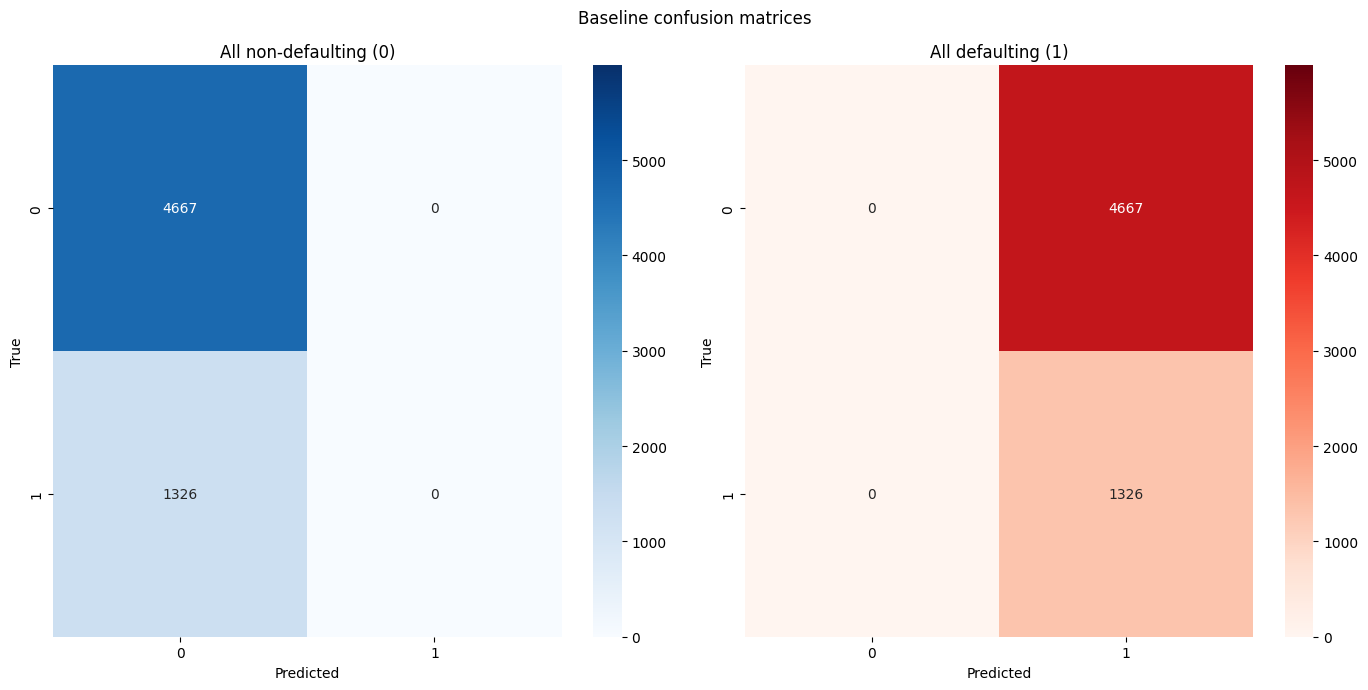

In [20]:
# Generate predictions on test set
preds_all_0 = np.zeros(len(test_target), dtype=int)
preds_all_1 = np.ones(len(test_target), dtype=int)

# Calculate custom value metrics
value_all_0 = custom_value_metric(test_target, preds_all_0, test_ead) / len(test_target)
value_all_1 = custom_value_metric(test_target, preds_all_1, test_ead) / len(test_target)

# Print baseline values
print(f"All non-defaulting (0): {value_all_0:.2f}$ per customer")
print(f"All defaulting (1): {value_all_1:.2f}$ per customer")

# Confusion matrices
conf_matrix_0 = sklearn.metrics.confusion_matrix(test_target, preds_all_0)
conf_matrix_1 = sklearn.metrics.confusion_matrix(test_target, preds_all_1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.heatmap(conf_matrix_0, annot=True, fmt='.0f', cmap='Blues', vmin=0, vmax=len(test_target), xticklabels=[0,1], yticklabels=[0,1], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("All non-defaulting (0)")

sns.heatmap(conf_matrix_1, annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=len(test_target), xticklabels=[0,1], yticklabels=[0,1], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("All defaulting (1)")

plt.suptitle("Baseline confusion matrices")
plt.tight_layout()
plt.show()

The dummy model *"Predict all 0s"* (i.e. accept and keep everyone) gets the better value, so we set our baseline at a profit of +12.65$ per customer per month.

### 3.2 Parallel Grid & Threshold Optimization Framework

To systematically fine-tune model hyperparameters, a helper function is created

Standard cross-validation tools (like `GridSearchCV`) optimize for metrics at a rigid default threshold of $0.5$. Our custom helper function will instead treat the **decision threshold as a first-class hyperparameter**, outputting the best N configurations over a validation set.

The function is specifically made for time and resource constrained environments where keeping a machine running continuously is not doable. For this reason, a checkpoint logic is implemented, making it possible to stop and resume the search without losing any progress

In [21]:
def find_best_n_combinations_cv(
    estimator,
    param_grid,
    thresholds,
    X_train,
    y_train,
    ead_train,
    custom_metric_func,
    n_splits=5,
    top_n=10,
    checkpoint_file="checkpoint.json",
    results_file="gridsearch_results.csv"
):
    """
    Find the best N hyperparameter combinations based on cross-validation performance and thresholds.
    """
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    model_combinations = list(itertools.product(*param_values))
    total_runs = len(model_combinations)

    folds = list(   # Stratified K-Fold cross-validation to maintain class distribution across folds
        sklearn.model_selection.StratifiedKFold(
            n_splits=n_splits, shuffle=True, random_state=42
        ).split(X_train, y_train)
    )

    start_idx = 0
    all_results = []

    # Load checkpoint
    if os.path.exists(checkpoint_file):
        try:
            with open(checkpoint_file, "r") as f:
                ckpt = json.load(f)

            start_idx = ckpt["last_completed_idx"]
            all_results = ckpt["results"]

            print(
                f"=== Checkpoint found! Resuming from "
                f"{start_idx + 1}/{total_runs} ==="
            )

        except Exception as e:
            print(
                f"=== Error loading checkpoint ({e}). "
                "Starting from scratch. ==="
            )
    else:
        print(
            f"=== CV GridSearch: {total_runs} combinations x "
            f"{n_splits} folds x {len(thresholds)} thresholds "
            f"({total_runs * n_splits * len(thresholds)} total) ==="
        )

    if start_idx >= total_runs:
        print("=== Already completed! ===")
        return

    checkpoint_step = max(1, total_runs // 100) # Save checkpoint every 1% of total combinations

    X_arr = np.array(X_train)
    y_arr = np.array(y_train)
    ead_arr = np.array(ead_train)

    start_time = time.time()

    for idx in range(start_idx, total_runs): # Iterate over all hyperparameter combinations
        current_params = dict(zip(param_names, model_combinations[idx]))

        fold_val_indices = []
        oof_probs_raw = np.zeros(len(X_arr))

        # OOF predictions
        for train_idx, val_idx in folds:
            model = sklearn.base.clone(estimator)
            model.set_params(**current_params)
            model.fit(X_arr[train_idx], y_arr[train_idx])

            oof_probs_raw[val_idx] = model.predict_proba(X_arr[val_idx])[:, 1]

            fold_val_indices.append(val_idx)

        
        oof_probs_calibrated = calibrate_probabilities(oof_probs_raw, pi_train=0.2213, pi_real=0.003)

        # Evaluate over different thresholds
        for t in thresholds:
            preds = (oof_probs_calibrated >= t).astype(int)

            fold_profits = [
                custom_metric_func(
                    y_arr[val_idx], preds[val_idx], ead_arr[val_idx]
                )
                / len(val_idx)
                for val_idx in fold_val_indices
            ]

            cv_mean = float(np.mean(fold_profits))
            cv_std = float(np.std(fold_profits))

            all_results.append(
                {
                    **current_params,
                    "threshold": round(float(t), 3),
                    "cv_profit_mean": round(cv_mean, 2),
                    "cv_profit_std": round(cv_std, 2),
                }
            )

        current_model_number = idx + 1

        # Checkpoint saving
        if current_model_number % checkpoint_step == 0 or current_model_number == total_runs:
            print(
                f"-> Progress: {current_model_number}/{total_runs} "
                f"| Block time: {time.time() - start_time:.2f}s"
            )

            df_temp = pd.DataFrame(all_results)

            # Keep only the top N combinations by mean profit
            df_temp = df_temp.sort_values(
                "cv_profit_mean", ascending=False
            ).head(top_n)

            all_results = df_temp.to_dict(orient="records")

            with open(checkpoint_file, "w") as f:
                json.dump(
                    {
                        "last_completed_idx": current_model_number,
                        "results": all_results,
                    },
                    f,
                    indent=4,
                )

            print(
                f"-> [Checkpoint] Best mean so far: "
                f"{all_results[0]['cv_profit_mean']} "
                f"(std={all_results[0]['cv_profit_std']})"
            )

            start_time = time.time()

    # Final results
    df_results = pd.DataFrame(all_results)
    df_results = df_results.sort_values(
        "cv_profit_mean", ascending=False
    ).reset_index(drop=True).head(top_n)

    os.makedirs("./models/gridsearches", exist_ok=True)

    df_results.to_csv(f"./models/gridsearches/{results_file}", index=False)

*NOTE: For time constraints, the full GridSearches are not executed in this notebook. Only final results and the code used to generate them are provided for reproducibility.*

After having computed a baseline, various classification model will be tested:
* As previously discussed, **Linear models** are expected to perform competitively (Logistic Regression models will be tested)
* **Tree and Ensemble models** are only expected to achieve marginal gains under normal conditions (Random Forest and Gradient Boosting models will be tested)
* **Neural Networks** will be excluded due to their lack in interpretability and diminishing returns

---

*OTHER NOTE: in every gridsearch, class weights / positive scale weights will not be modified, as the Prior Probability Threshold Correction Formula already expects weight = distribution*

### 3.3 Logistic Regression

Code used to find the best hyper-parameters:

```python
base_lr = sklearn.linear_model.LogisticRegression(
    solver='saga', 
    random_state=42, 
    max_iter=10000,
    class_weight=None
)

lr_hyperparams = {
    'C':            [0.001, 0.005, 0.01, 0.1, 1.0, 5.0, 10.0],
    'l1_ratio':     [0.0, 0.5, 1.0]
}

threshold_grid = np.arange(0.001, 0.031, 0.001)  # 0.1% to 3%

top_combinations = find_best_n_combinations_cv(
    estimator=base_lr,
    param_grid=lr_hyperparams,
    thresholds=threshold_grid,
    X_train=train_input,
    y_train=train_target,
    ead_train=train_ead,
    custom_metric_func=custom_value_metric,
    n_splits=5,
    top_n=10,
    checkpoint_file="checkpoint_LR.json",
    results_file="gridsearch_results_LR.csv"
)

results = pd.read_csv("./models/gridsearches/gridsearch_results_LR.csv")

results.head(10)
```

---

Output:

| Rank | C | l1_ratio | threshold | cv_profit_mean | cv_profit_std |
|---|---|---|---|---|---|
| 1 | 0.001 | 1.0 | 0.006 | 13.38 | 0.31 |
| 2 | 0.005 | 1.0 | 0.007 | 13.31 | 0.32 |
| 3 | 0.005 | 1.0 | 0.008 | 13.31 | 0.34 |
| 4 | 0.001 | 1.0 | 0.005 | 13.30 | 0.33 |
| 5 | 0.001 | 0.5 | 0.007 | 13.29 | 0.32 |
| 6 | 0.001 | 0.5 | 0.006 | 13.29 | 0.29 |
| 7 | 0.010 | 1.0 | 0.008 | 13.29 | 0.32 |
| 8 | 0.010 | 1.0 | 0.007 | 13.28 | 0.34 |
| 9 | 0.005 | 0.5 | 0.008 | 13.28 | 0.32 |
| 10 | 0.010 | 0.0 | 0.008 | 13.27 | 0.34 |

From the latest GridSearch on our Logistic Regression model, several insights can be derived:

* **Severe regularization ($C = 0.001 - 0.01$) consistently outperforms lighter alternatives:** Given the absence of multicollinearity in our feature space, this necessity for extreme penalty points to a low signal-to-noise ratio. Individual predictors carry relatively weak, noisy signals; heavy coefficient shrinkage is therefore mandatory to stabilize the model and prevent it from overfitting to random fluctuations.

* **L1 regularization actively enforces sparsity:** The top-performing models show a clear preference for pure Lasso ($L_1$) regularization, while the bottom-performing ones prefer a 50/50 split between L1 Lasso and L2 Ridge. In a noisy environment, this behavior works as an automated feature selection tool, aggressively driving uninformative parameters to zero and isolating only the core, macro-level drivers of default.

* **Decision threshold locks a clear preference:** while the model had the possibility to use higher thresholds (up to 0.03 i.e. 3%), all of the best performing models settle for a lower boundary between 0.006 and 0.008 (0.6% to 0.8%), above our "realistic default ratio" of 0.3% but still noteceably lower than the original 22.13% presence in the original dataset, proving that the combination of loss/gain adjusting (with `w_pos` and `w_neg`) and probability transformation worked as intended

We'll select two Logistic Regression configurations for the final evaluation phase. Rather than choosing the two highest-scoring models, we intentionally select models with different decision strategies to assess the robustness of the approach under real-world conditions and future stress scenarios.

Based on the mean profit and standard deviation across the cross-validation folds, we select the 1st and 10th ranked configurations. The top-ranked model uses a lower decision threshold (0.006) and applies a harsher (C = 0.001) pure L1 regularization strategy (l1_ratio = 1.0), whereas the second  adopts a slightly higher threshold (0.008) with a less harsh regularization (C = 0.010) pure-L2 strategy.

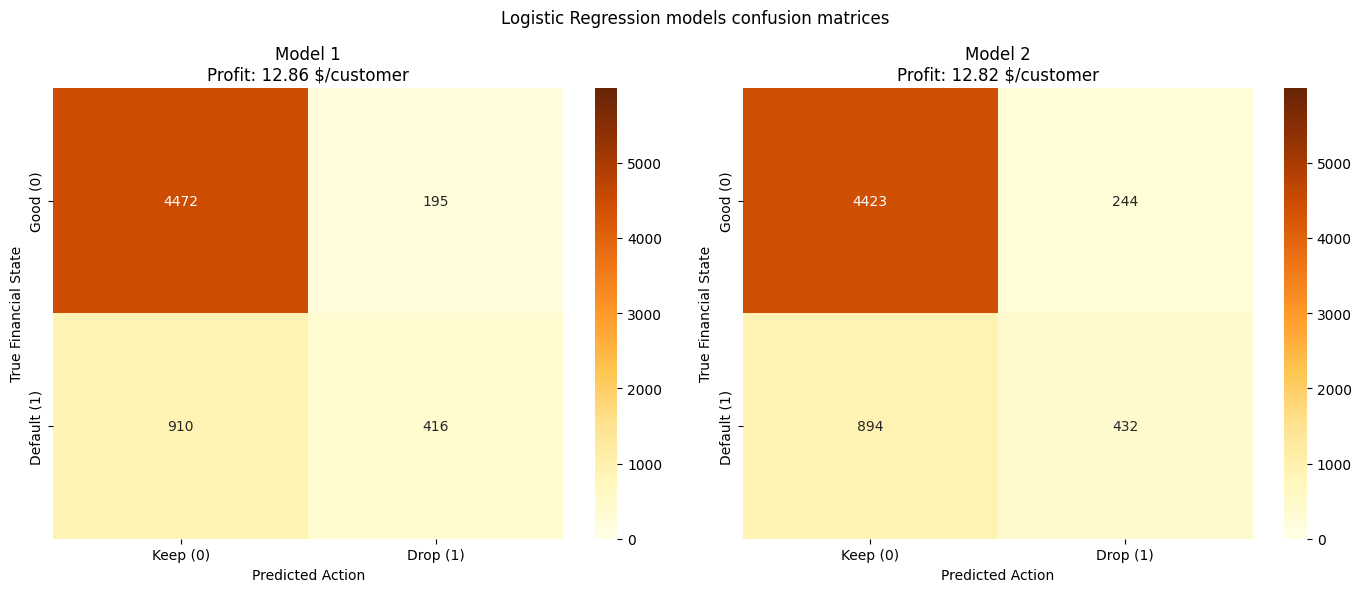

In [22]:
### LOGISTIC REGRESSION BEST MODELS

## MODEL 1 (C=0.001, l1_ratio=1.00, threshold=0.006)

lr_model_1 = sklearn.linear_model.LogisticRegression(
    solver='saga',
    random_state=42,
    max_iter=10000,
    class_weight=None,
    C=0.001,
    l1_ratio=1.00
)

lr_model_1.fit(train_input, train_target)

probs_lr_1 = lr_model_1.predict_proba(test_input)[:, 1]
test_preds_lr_1 = (calibrate_probabilities(probs_lr_1) >= 0.006).astype(int)

profit_m1 = round(custom_value_metric(test_target, test_preds_lr_1, test_ead) / len(test_target), 2)
conf_matrix_m1 = sklearn.metrics.confusion_matrix(test_target, test_preds_lr_1)

models_dict["LR_Model_1"] = lr_model_1

## MODEL 2 (C=0.010, l1_ratio=0.00, threshold=0.008)

lr_model_2 = sklearn.linear_model.LogisticRegression(
    solver='saga',
    random_state=42, 
    max_iter=10000,
    class_weight=None,
    C=0.010,
    l1_ratio=0.00
)

lr_model_2.fit(train_input, train_target)

probs_lr_2 = lr_model_2.predict_proba(test_input)[:, 1]
test_preds_lr_2 = (calibrate_probabilities(probs_lr_2) >= 0.008).astype(int)

profit_m2 = round(custom_value_metric(test_target, test_preds_lr_2, test_ead) / len(test_target), 2)
conf_matrix_m2 = sklearn.metrics.confusion_matrix(test_target, test_preds_lr_2)

models_dict["LR_Model_2"] = lr_model_2

## PLOT CONFUSION MATRICES

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

## Heatmap Model 1
sns.heatmap(
    conf_matrix_m1, 
    annot=True, 
    fmt='.0f', 
    cmap='YlOrBr', 
    vmin=0, 
    vmax=len(test_target), 
    xticklabels=['Keep (0)', 'Drop (1)'], 
    yticklabels=['Good (0)', 'Default (1)'], 
    ax=axes[0]
)
axes[0].set_xlabel("Predicted Action")
axes[0].set_ylabel("True Financial State")
axes[0].set_title(f"Model 1\nProfit: {profit_m1} $/customer")

## Heatmap Model 2
sns.heatmap(
    conf_matrix_m2, 
    annot=True, 
    fmt='.0f', 
    cmap='YlOrBr',
    vmin=0, 
    vmax=len(test_target), 
    xticklabels=['Keep (0)', 'Drop (1)'], 
    yticklabels=['Good (0)', 'Default (1)'],
    ax=axes[1]
)
axes[1].set_xlabel("Predicted Action")
axes[1].set_ylabel("True Financial State")
axes[1].set_title(f"Model 2\nProfit: {profit_m2} $/customer")

plt.suptitle("Logistic Regression models confusion matrices")
plt.tight_layout()
plt.show()

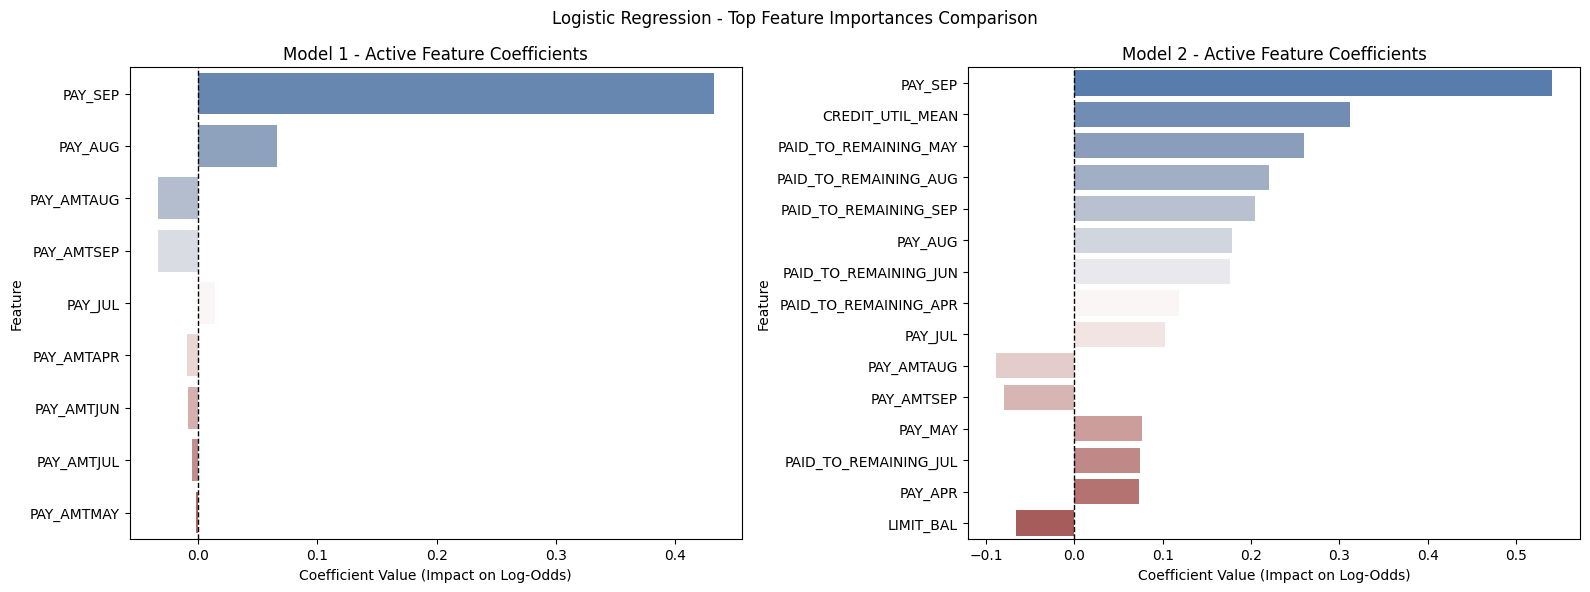

Model 1: 9 feature active over 21
Model 2: 21 feature active over 21


In [23]:
## PLOT FEATURE IMPORTANCES (COEFFICIENTS)

coefs_m1 = pd.DataFrame({
    'Feature': train_input.columns,
    'Coefficient': lr_model_1.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

coefs_m2 = pd.DataFrame({
    'Feature': train_input.columns,
    'Coefficient': lr_model_2.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)

# Filter for non-zero
non_zero_m1 = coefs_m1[coefs_m1['Coefficient'] != 0]
non_zero_m2 = coefs_m2[coefs_m2['Coefficient'] != 0]

## PLOTS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

## Barplot Model 1
sns.barplot(
    data=non_zero_m1.head(15), # Top 15
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette='vlag',
    ax=axes[0]
)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title("Model 1 - Active Feature Coefficients")
axes[0].set_xlabel("Coefficient Value (Impact on Log-Odds)")

## Barplot Model 2
sns.barplot(
    data=non_zero_m2.head(15), # Top 15
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette='vlag',
    ax=axes[1]
)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("Model 2 - Active Feature Coefficients")
axes[1].set_xlabel("Coefficient Value (Impact on Log-Odds)")

plt.suptitle("Logistic Regression - Top Feature Importances Comparison")
plt.tight_layout()
plt.show()

# Check active features count
print(f"Model 1: {len(non_zero_m1)} feature active over {len(train_input.columns)}")
print(f"Model 2: {len(non_zero_m2)} feature active over {len(train_input.columns)}")

---

### 3.4 Random Forest

Code used to find the best hyper-parameters:

```python
base_rf = sklearn.ensemble.RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    class_weight=None,
    criterion="gini"
)

rf_hyperparams = {
    'n_estimators':      [100, 200, 400],
    'max_depth':         [5, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf':  [2, 4],
    'max_features':      ['log2', 0.3, 0.5]
}

threshold_grid = np.arange(0.001, 0.031, 0.001)  # 0.1% to 3%

top_combinations = find_best_n_combinations_cv(
    estimator=base_rf,
    param_grid=rf_hyperparams,
    thresholds=threshold_grid,
    X_train=train_input,
    y_train=train_target,
    ead_train=train_ead,
    custom_metric_func=custom_value_metric,
    n_splits=5,
    top_n=10,
    checkpoint_file="checkpoint_RF.json",
    results_file="gridsearch_results_RF.csv"
)

results = pd.read_csv("./models/gridsearches/gridsearch_results_RF.csv")

results.head(10)
```

---

Output:

| Rank | n_estimators | max_depth | min_samples_split | min_samples_leaf | max_features | threshold | cv_profit_mean | cv_profit_std |
|---|---|---|---|---|---|---|---|---|
| 1 | 100 | 10 | 5 | 2 | 0.5 | 0.016 | 13.45 | 0.34 |
| 2 | 400 | 10 | 5 | 2 | 0.5 | 0.017 | 13.44 | 0.32 |
| 3 | 100 | 10 | 10 | 2 | 0.3 | 0.016 | 13.43 | 0.33 |
| 4 | 100 | 10 | 10 | 2 | 0.3 | 0.013 | 13.43 | 0.31 |
| 5 | 100 | 10 | 5 | 2 | 0.5 | 0.017 | 13.43 | 0.33 |
| 6 | 100 | 10 | 10 | 2 | 0.3 | 0.014 | 13.43 | 0.30 |
| 7 | 100 | 10 | 10 | 4 | 0.5 | 0.016 | 13.43 | 0.31 |
| 8 | 100 | 10 | 5 | 4 | 0.5 | 0.019 | 13.43 | 0.32 |
| 9 | 100 | 10 | 5 | 2 | 0.5 | 0.015 | 13.43 | 0.34 |
| 10 | 400 | 15 | 5 | 2 | 0.3 | 0.015 | 13.42 | 0.33 |

After having extensively trained Random Forest model, new structural insights regarding dataset and model behavior can be derived:

* **Non-linear feature interactions unlock limited value:** Moving from the linear constraints of Logistic Regression to Random Forest drives the net yield up to just **$13.44 per customer**, possibly confirming our initial assumption on the data, where linear models capture most of the value, while more complex architectures only return marginal gains 

* **Controlled depth and tight feature subsampling prevent noise memorization:** The clear ceiling at `max_depth = 10` paired with a restricted feature set (`max_features = 0.3 - 0.5`) serves as the optimal regularizer. Restricting each split to evaluate at most half of the available features ensures good tree diversity within the ensemble.

* **The financial decision boundary steps up from Logistic Regression:** Across almost all top configurations, the business logic converges onto a decision threshold situated between $0.014$ and $0.017$. This mis-alignment with Logistic Regression models could possibly indicate a less harsh default-predicting strategy 

* **Other parameters also seem to converge:** Top model show clear preferences for the overfitting-preventing parameter `min_samples_split`, converging to $2$ for the majority of the top models, while `min_samples_split` doesn't seem to be as crucial, and the number of estimators seems to stabilize at the lowest value of 100 for 8/10 of the best models

Again, two Random Forest configurations will be retained for final validation. Rank 2 is selected as the primary production candidate due to its higher profitability and improved stability (lower std between folds). Rank 10 is a selected as a structurally diverse alternative, introducing deeper tress with a smaller per-tree feature set, allowing us to test different predictive strategies under future tests and production

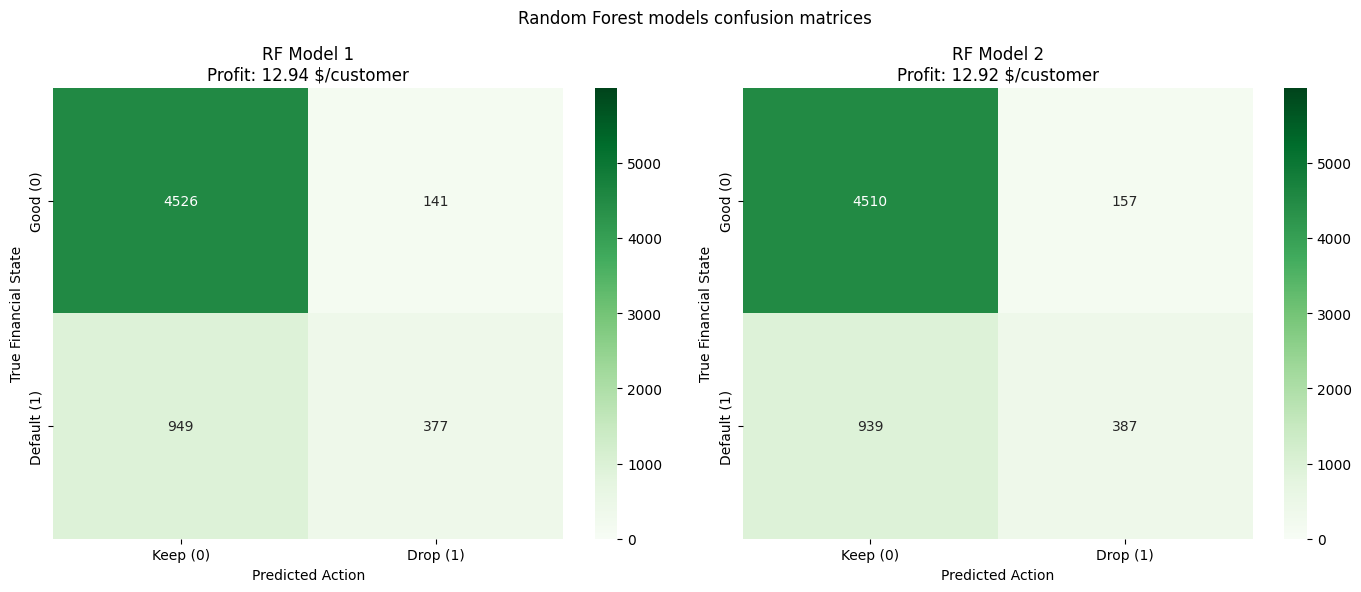

In [24]:
### RANDOM FOREST BEST MODELS

## MODEL 1 (n_estimators=400, max_depth=10, min_samples_split=5, min_samples_leaf=2, max_features=0.5, threshold=0.017)

rf_model_1 = sklearn.ensemble.RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    class_weight=None,
    criterion='gini',
    n_estimators=400,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.5
)

rf_model_1.fit(train_input, train_target)

probs_rf_1 = rf_model_1.predict_proba(test_input)[:, 1]
test_preds_rf_1 = (calibrate_probabilities(probs_rf_1) >= 0.017).astype(int)

profit_rf1 = round(custom_value_metric(test_target, test_preds_rf_1, test_ead) / len(test_target), 2)
conf_matrix_rf1 = sklearn.metrics.confusion_matrix(test_target, test_preds_rf_1)

models_dict["RF_Model_1"] = rf_model_1


## MODEL 2 (n_estimators=400, max_depth=15, min_samples_split=5, min_samples_leaf=2, max_features=0.3, threshold=0.015)

rf_model_2 = sklearn.ensemble.RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    bootstrap=True,
    class_weight=None,
    criterion='gini',
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.3
)

rf_model_2.fit(train_input, train_target)

probs_rf_2 = rf_model_2.predict_proba(test_input)[:, 1]
test_preds_rf_2 = (calibrate_probabilities(probs_rf_2) >= 0.015).astype(int)

profit_rf2 = round(custom_value_metric(test_target, test_preds_rf_2, test_ead) / len(test_target), 2)
conf_matrix_rf2 = sklearn.metrics.confusion_matrix(test_target, test_preds_rf_2)

models_dict["RF_Model_2"] = rf_model_2


## PLOT CONFUSION MATRICES

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

## Heatmap Model 1
sns.heatmap(
    conf_matrix_rf1, 
    annot=True, 
    fmt='.0f', 
    cmap='Greens', 
    vmin=0, 
    vmax=len(test_target), 
    xticklabels=['Keep (0)', 'Drop (1)'], 
    yticklabels=['Good (0)', 'Default (1)'], 
    ax=axes[0]
)
axes[0].set_xlabel("Predicted Action")
axes[0].set_ylabel("True Financial State")
axes[0].set_title(f"RF Model 1\nProfit: {profit_rf1} $/customer")

## Heatmap Model 2
sns.heatmap(
    conf_matrix_rf2, 
    annot=True, 
    fmt='.0f', 
    cmap='Greens',
    vmin=0, 
    vmax=len(test_target), 
    xticklabels=['Keep (0)', 'Drop (1)'], 
    yticklabels=['Good (0)', 'Default (1)'],
    ax=axes[1]
)
axes[1].set_xlabel("Predicted Action")
axes[1].set_ylabel("True Financial State")
axes[1].set_title(f"RF Model 2\nProfit: {profit_rf2} $/customer")

plt.suptitle("Random Forest models confusion matrices")
plt.tight_layout()
plt.show()

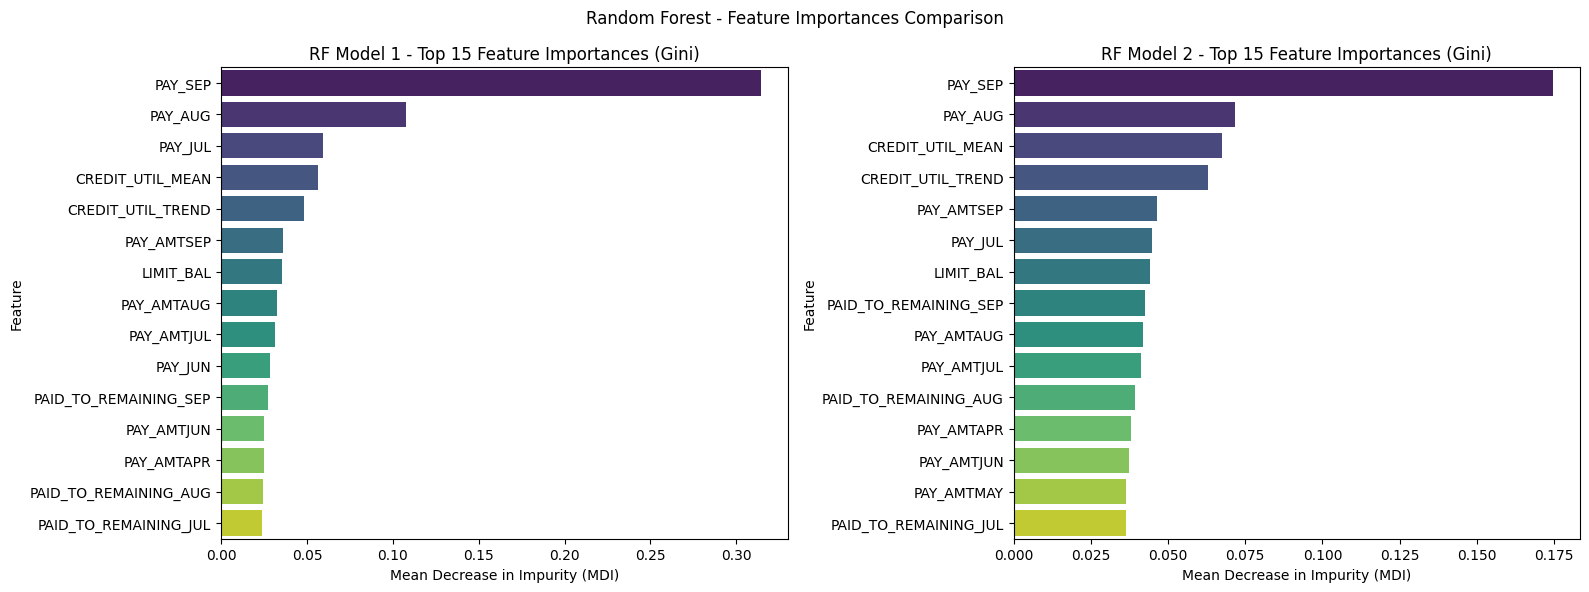

In [25]:
## PLOT RF FEATURE IMPORTANCES (GINI-reduction based)

importances_rf1 = pd.DataFrame({
    'Feature': train_input.columns,
    'Importance': rf_model_1.feature_importances_
}).sort_values(by='Importance', ascending=False)

importances_rf2 = pd.DataFrame({
    'Feature': train_input.columns,
    'Importance': rf_model_2.feature_importances_
}).sort_values(by='Importance', ascending=False)

## PLOTS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

## Barplot RF Model 1
sns.barplot(
    data=importances_rf1.head(15), # Top 15
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title("RF Model 1 - Top 15 Feature Importances (Gini)")
axes[0].set_xlabel("Mean Decrease in Impurity (MDI)")

## Barplot RF Model 2
sns.barplot(
    data=importances_rf2.head(15), # Top 15
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("RF Model 2 - Top 15 Feature Importances (Gini)")
axes[1].set_xlabel("Mean Decrease in Impurity (MDI)")

plt.suptitle("Random Forest - Feature Importances Comparison")
plt.tight_layout()
plt.show()

Comparing our two Random Forest models to the previous Logistic Regression ones, we can see that although Logistic Regression models are slightly more selective, increasing correctly dropped defaulting customers by approximately **5% to 15%**, this trade-off is compensated by Random Forest's ability to retain between **1.1% and 2.3% more** more non-defaulting customers that Logistic Regression models would have incorrectly dropped, which adjusted on the real distributions of classes (99.7/0.3), is enough to explain the superiority of Random Forest on this dataset

---

### 3.5 Gradient Boosting

Code used to find the best hyper-parameters:

```python
base_xgb = xgboost.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist',
    subsample=0.8,
    scale_pos_weight=1
)

xgb_hyperparams = {
    'n_estimators':     [100, 200, 300],
    'learning_rate':    [0.025, 0.05, 0.1],
    'max_depth':        [4, 6, 8],
    'min_child_weight': [1, 3, 5],
    'colsample_bytree': [0.4, 0.7],
    'reg_alpha':        [0.0, 1.0, 5.0],
    'reg_lambda':       [1.0, 5.0, 10.0],
}

threshold_grid = np.arange(0.001, 0.031, 0.001)  # 0.1% to 3%

top_combinations = find_best_n_combinations_cv(
    estimator=base_xgb,
    param_grid=xgb_hyperparams,
    thresholds=threshold_grid,
    X_train=train_input,
    y_train=train_target,
    ead_train=train_ead,
    custom_metric_func=custom_value_metric,
    n_splits=5,
    top_n=10,
    checkpoint_file="checkpoint_XGB.json",
    results_file="gridsearch_results_XGB.csv"
)

results = pd.read_csv("./models/gridsearches/gridsearch_results_XGB.csv")

results.head(10)
```

---

Output:

| Rank | n_estimators | learning_rate | max_depth | min_child_weight | colsample_bytree | reg_alpha | reg_lambda | threshold | cv_profit_mean | cv_profit_std |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 100 | 0.100 | 8 | 1 | 0.7 | 0.0 | 10.0 | 0.014 | 13.43 | 0.31 |
| 2 | 100 | 0.100 | 8 | 1 | 0.7 | 5.0 | 5.0 | 0.013 | 13.42 | 0.35 |
| 3 | 300 | 0.050 | 6 | 5 | 0.7 | 0.0 | 5.0 | 0.014 | 13.42 | 0.32 |
| 4 | 100 | 0.050 | 8 | 3 | 0.7 | 1.0 | 10.0 | 0.014 | 13.42 | 0.35 |
| 5 | 200 | 0.050 | 6 | 3 | 0.7 | 1.0 | 10.0 | 0.016 | 13.41 | 0.34 |
| 6 | 100 | 0.050 | 8 | 5 | 0.7 | 1.0 | 10.0 | 0.014 | 13.41 | 0.36 |
| 7 | 300 | 0.050 | 6 | 3 | 0.4 | 0.0 | 10.0 | 0.014 | 13.41 | 0.32 |
| 8 | 200 | 0.050 | 6 | 3 | 0.7 | 1.0 | 10.0 | 0.015 | 13.41 | 0.34 |
| 9 | 300 | 0.025 | 8 | 1 | 0.7 | 1.0 | 5.0 | 0.016 | 13.41 | 0.32 |
| 10 | 100 | 0.100 | 6 | 5 | 0.7 | 0.0 | 5.0 | 0.013 | 13.41 | 0.31 |

From this last GridSearch on our XGBoost model, final educated conclusions regarding our data can be made:

* **XGBoost falls in the same performance interval as RF (if not worse):** While the gradient boosting architecture is generally seen as the "State-Of-The-Art" for ML modeling and production, this latest gridsearch shows a different story. Failing to break RF's mean profit barrier without even achieving a lower fold variance is coherent with the reality of ML, where no model can be "generally the best" in every scenario, and that deep business analysis is needed for each goal and project

* **Heavy structural and mathematical regularization is mandatory to defeat noise:** The absolute winners paired moderate and harsh leaf penalties (`min_child_weight = 3`, `reg_alpha = 0.0 - 5.0`, and `reg_lambda = 5.0 - 10.0`) for a highly regularized configuration

* **Universal convergence on the 0.013 - 0.016 Threshold:** Across almost all ensemble top-performing configurations, the business logic independently locks onto the **$0.013$ - $0.016$** decision threshold range (in line with Bayes's optimal threshold formula, which returns $\approx 1.64\%$), again possibly indicating the clear optimal business threshold for maximum performance.

Two XGBoost configurations are then saved for final evaluation. Rank 1 is selected as the primary candidate due to its optimal std-adjusted profitability. Rank 3 is chosen as a structurally differentiated alternative, introducing a less regularized learning process (`reg_alpha = 0.0`, `reg_lambda = 5.0`),  shallower trees (`max_depth = 6`), half the learning rate (`learning_rate = 0.050`), triple the total estimators (`n_estimators = 300`), and a higher min_child_weight ($5$)

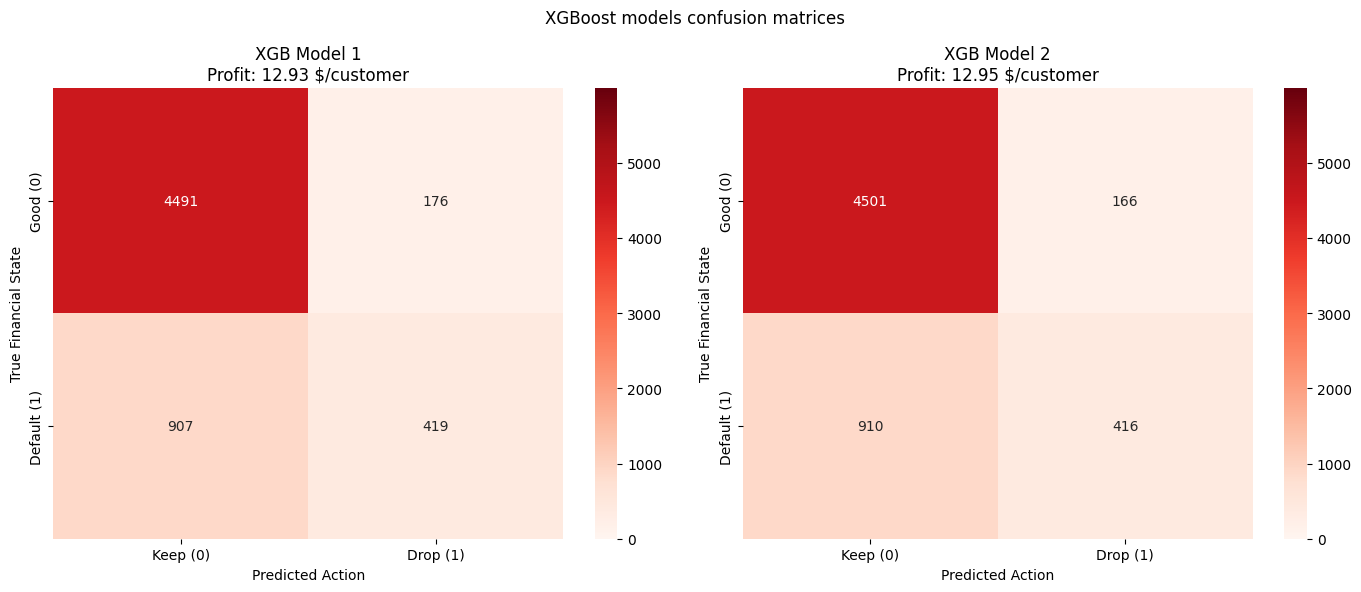

In [26]:
### XGBOOST BEST MODELS

## MODEL 1 (n_estimators=100, learning_rate=0.100, max_depth=8, min_child_weight=1, colsample_bytree=0.7, reg_alpha=0.0, reg_lambda=10.0, threshold=0.014)

xgb_model_1 = xgboost.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist',
    subsample=0.8,
    scale_pos_weight=1,
    n_estimators=100,
    learning_rate=0.100,
    max_depth=8,
    min_child_weight=1,
    colsample_bytree=0.7,
    reg_alpha=0.0,
    reg_lambda=10.0
)

xgb_model_1.fit(train_input, train_target)

probs_xgb_1 = xgb_model_1.predict_proba(test_input)[:, 1]
test_preds_xgb_1 = (calibrate_probabilities(probs_xgb_1) >= 0.014).astype(int)

profit_xgb1 = round(custom_value_metric(test_target, test_preds_xgb_1, test_ead) / len(test_target), 2)
conf_matrix_xgb1 = sklearn.metrics.confusion_matrix(test_target, test_preds_xgb_1)

models_dict["XGB_Model_1"] = xgb_model_1


## MODEL 2 (n_estimators=300, learning_rate=0.050, max_depth=6, min_child_weight=5, colsample_bytree=0.7, reg_alpha=0.0, reg_lambda=5.0, threshold=0.014)

xgb_model_2 = xgboost.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist',
    subsample=0.8,
    scale_pos_weight=1,
    n_estimators=300,
    learning_rate=0.050,
    max_depth=6,
    min_child_weight=5,
    colsample_bytree=0.7,
    reg_alpha=0.0,
    reg_lambda=5.0
)

xgb_model_2.fit(train_input, train_target)

probs_xgb_2 = xgb_model_2.predict_proba(test_input)[:, 1]
test_preds_xgb_2 = (calibrate_probabilities(probs_xgb_2) >= 0.014).astype(int)

profit_xgb2 = round(custom_value_metric(test_target, test_preds_xgb_2, test_ead) / len(test_target), 2)
conf_matrix_xgb2 = sklearn.metrics.confusion_matrix(test_target, test_preds_xgb_2)


models_dict["XGB_Model_2"] = xgb_model_2

### PLOT CONFUSION MATRICES

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

## Heatmap Model 1
sns.heatmap(
    conf_matrix_xgb1, 
    annot=True, 
    fmt='.0f', 
    cmap='Reds', 
    vmin=0, 
    vmax=len(test_target), 
    xticklabels=['Keep (0)', 'Drop (1)'], 
    yticklabels=['Good (0)', 'Default (1)'], 
    ax=axes[0]
)
axes[0].set_xlabel("Predicted Action")
axes[0].set_ylabel("True Financial State")
axes[0].set_title(f"XGB Model 1\nProfit: {profit_xgb1} $/customer")

## Heatmap Model 2
sns.heatmap(
    conf_matrix_xgb2, 
    annot=True, 
    fmt='.0f', 
    cmap='Reds',
    vmin=0, 
    vmax=len(test_target), 
    xticklabels=['Keep (0)', 'Drop (1)'], 
    yticklabels=['Good (0)', 'Default (1)'],
    ax=axes[1]
)
axes[1].set_xlabel("Predicted Action")
axes[1].set_ylabel("True Financial State")
axes[1].set_title(f"XGB Model 2\nProfit: {profit_xgb2} $/customer")

plt.suptitle("XGBoost models confusion matrices")
plt.tight_layout()
plt.show()

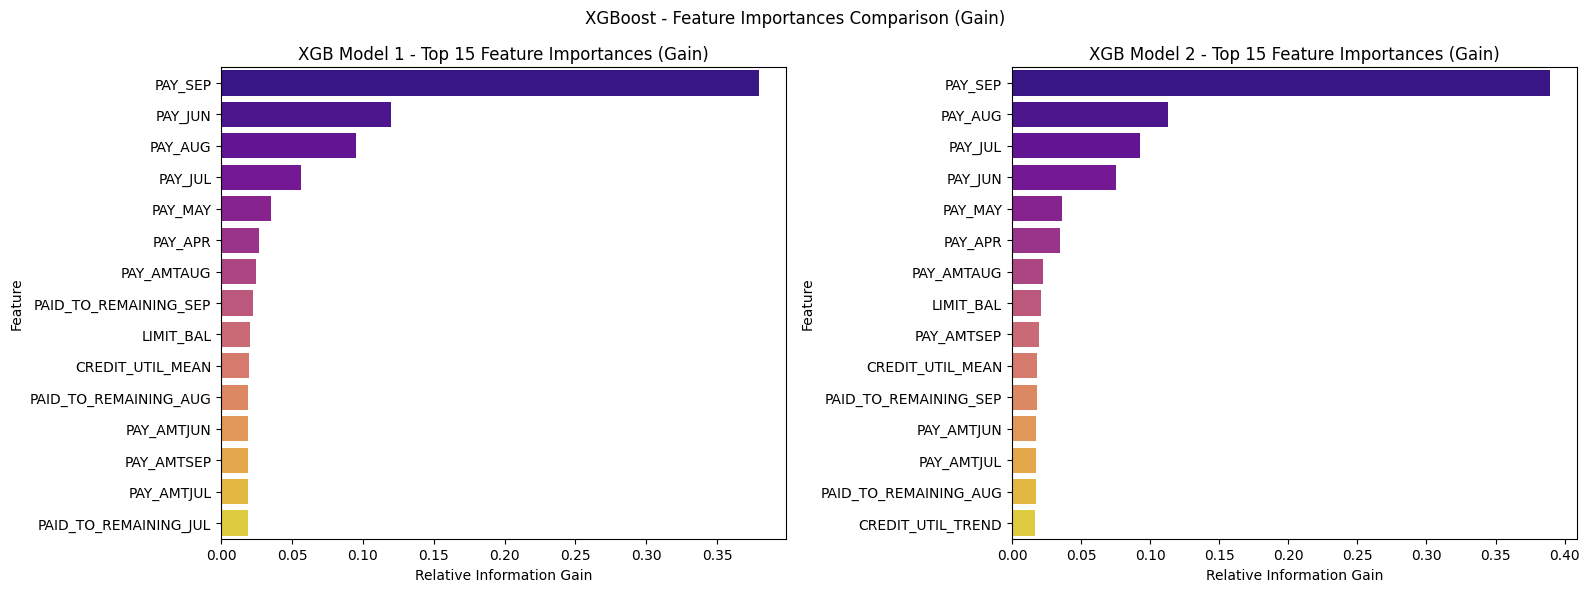

In [27]:
## PLOT XGB FEATURE IMPORTANCES

importances_xgb1 = pd.DataFrame({
    'Feature': train_input.columns,
    'Importance': xgb_model_1.feature_importances_
}).sort_values(by='Importance', ascending=False)

importances_xgb2 = pd.DataFrame({
    'Feature': train_input.columns,
    'Importance': xgb_model_2.feature_importances_
}).sort_values(by='Importance', ascending=False)

## PLOTS

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

## Barplot Model 1
sns.barplot(
    data=importances_xgb1.head(15), 
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='plasma', 
    ax=axes[0]
)
axes[0].set_title("XGB Model 1 - Top 15 Feature Importances (Gain)")
axes[0].set_xlabel("Relative Information Gain")

## Barplot Model 2
sns.barplot(
    data=importances_xgb2.head(15), 
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='plasma',
    ax=axes[1]
)
axes[1].set_title("XGB Model 2 - Top 15 Feature Importances (Gain)")
axes[1].set_xlabel("Relative Information Gain")

plt.suptitle("XGBoost - Feature Importances Comparison (Gain)")
plt.tight_layout()
plt.show()

From a feature importance perspective, both XGBoost configurations maintain consistent feature importance patterns, giving more importance to payments statuses rather than amounts or credit usage in contrast with Random Forests.

From a confusion matrix read instead, Random Forests maintain their superiority when correctly identifying non-defaulting customers (the only source of revenue) even at the expense of keeping more defaulting clients, making the top XGBoost models comparable to the performance of the simpler Logistic Regressions

***IMPORTANT:** for every tested model, the Cross Validation mean profit was always higher than the profit calculated on the test set. This is common as by fine tuning hyperparameters we artificially introduce a form of overfitting. The final performance will only be calculated on the test set to ensure no artificial uplift in profits and a real-world performance*

## 4. Saving

Tested and stored our 2 best performing models for every architecture (Logistic Regression, Random Forest, Gradient Boosting) we save our datasets, along our best candidates for our next and final notebook, `04_Testing_and_deploying.ipynb`, where they will be compared on performance, robustness under noise, interpretability and real-use outcome

In [28]:
### DATASETS

datasets = {
    # raw
    "train_input_raw.csv": train_input_raw, 
    "test_input_raw.csv": test_input_raw,
    # preprocessed
    "train_input.csv": train_input, 
    "test_input.csv": test_input, 
    "train_target.csv": train_target, 
    "test_target.csv": test_target,
    # EADs
    "train_EAD.csv": train_EAD, 
    "test_EAD.csv": test_EAD
}

os.makedirs("./data/splits/raw", exist_ok=True)
os.makedirs("./data/splits/preprocessed", exist_ok=True)
os.makedirs("./data/splits/EADs", exist_ok=True)

for name, dataset in datasets.items():
    if "raw" in name: # raw
        dataset.to_csv(f"./data/splits/raw/{name}", index=True)
    elif "EAD" in name: # EADs
        dataset.to_csv(f"./data/splits/EADs/{name}", index=True)
    else: # preprocessed
        dataset.to_csv(f"./data/splits/preprocessed/{name}", index=True)

### MODELS

os.makedirs("./models", exist_ok=True)

for model_name, model_obj in models_dict.items(): # Save each model
    joblib.dump(model_obj, f"./models/{model_name}.joblib")

thresholds = {
    "LR_1": 0.006,
    "LR_2": 0.008,
    "RF_1": 0.017,
    "RF_2": 0.015,
    "XGB_1": 0.014,
    "XGB_2": 0.014
}

# Save thresholds for every model
joblib.dump(thresholds, "./models/decision_thresholds.joblib")

['./models/decision_thresholds.joblib']